In [13]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.5)

## MutRF vs SOTA

In [14]:
meg_ris = pd.DataFrame()
for file in os.listdir("results_rf"):
    data = file.split("_")[0]
    attr = file.split("_")[1]
    df = pd.read_csv(f"results_rf/{file}", index_col=0)
    df["data"] = data
    df["attr"] = attr
    meg_ris = pd.concat([meg_ris, df])
meg_ris['approach'] = 'FairRF'
meg_ris.head()

,Accuracy,Recall,Precision,F1,MCC,SPD,AOD,EOD,Run,data,attr,approach
0,0.659,0.573,0.580,0.576,0.434,0.171,0.110,0.171,0,drug,race,FairRF
1,0.680,0.600,0.604,0.602,0.466,0.146,0.062,0.112,0,drug,race,FairRF
2,0.680,0.594,0.606,0.599,0.465,0.155,0.080,0.128,0,drug,race,FairRF
3,0.689,0.614,0.621,0.617,0.486,0.100,0.008,0.007,0,drug,race,FairRF
4,0.700,0.621,0.624,0.622,0.500,0.117,0.030,0.085,0,drug,race,FairRF


In [15]:
rs_data = pd.DataFrame()
for file in os.listdir("results_rs"):
    data = file.split("_")[0]
    attr = file.split("_")[1]
    df = pd.read_csv(f"results_rs/{file}", index_col=0)
    df["data"] = data
    df["attr"] = attr
    rs_data = pd.concat([rs_data, df])
rs_data['approach'] = 'RS'
rs_data.head() 

,Accuracy,Recall,Precision,F1,MCC,SPD,AOD,EOD,Run,data,attr,approach
0,0.666,0.591,0.594,0.591,0.440,0.043,0.013,0.058,8,drug,race,RS
1,0.629,0.556,0.568,0.560,0.387,0.130,0.138,0.255,8,drug,race,RS
2,0.627,0.553,0.560,0.556,0.384,0.092,0.126,0.313,8,drug,race,RS
3,0.648,0.568,0.576,0.571,0.408,0.115,0.097,0.151,8,drug,race,RS
4,0.650,0.555,0.558,0.554,0.408,0.074,0.069,0.151,8,drug,race,RS


## Read most baselines

In [16]:
combined = meg_ris.copy(deep=True)
combined = pd.concat([combined, rs_data])
combined.drop(columns=['Run'], inplace=True)

In [ ]:
from itertools import product
import os
import pandas as pd
from collections import defaultdict
baselines = ["ad","demv","eop","rw"]
datasets = ["adult","bank","compas","german","mep"]
attrs = ["age","race","sex"]
for bl, dataset, attr in product(baselines, datasets,attrs):
    path = os.path.join("../bias_mitigation_methods",f"results_{bl}", dataset, attr)
    if not os.path.isdir(path):
        continue
    rounds = os.listdir(path)
    for r in rounds:
        df = pd.read_csv(os.path.join(path,r))
        for i,row in df.iterrows():
            model = row["model"]
            approach = bl + "-" + model
            content = [row["acc"],row["recall"],row["precision"],row["f1score"],row["mcc"],
                      abs(row["stat_par"]),abs(row["ao"]),abs(row["eq_odds"]),dataset,attr,approach]
            combined.loc[len(combined)] = content
        
combined.tail()

,Accuracy,Recall,Precision,F1,MCC,SPD,AOD,EOD,data,attr,approach
5206,0.790272,0.790272,0.794679,0.792404,0.284663,0.090294,0.044579,0.027804,mep,race,rw-cart
5207,0.861866,0.861866,0.845292,0.845047,0.422841,0.043401,0.007058,0.012283,mep,race,rw-logreg
5208,0.861234,0.861234,0.844181,0.840782,0.408785,0.028590,0.025977,0.055025,mep,race,rw-svm
5209,0.862076,0.862076,0.846842,0.848946,0.437164,0.077638,0.047211,0.066743,mep,race,rw-forest
5210,0.791746,0.791746,0.801142,0.796142,0.288865,0.086413,0.058099,0.069065,mep,race,rw-cart


## Read MAAT

In [ ]:
data_key_value_used = {1:'Acc', 2:'Mac-R', 3:'Mac-P', 4:'Mac-F1', 5:'MCC', 6:'SPD', 7:'AOD', 8:'EOD'}
for j in ['lr','rf','svm']:
    for name in ["maat"]:
        for dataset in ['Adult-Sex','Adult-Race','Compas-Sex','Compas-Race','German-Sex','Bank-Age','Mep-Race']:
            (dataset_pre,dataset_aft) = dataset.lower().split('-')
            if dataset == 'Mep-Race':
                dataset_pre = 'mep'
                dataset_aft = 'RACE'
            fin = open('../bias_mitigation_methods/results_maat/'+name+'_'+j+'_'+dataset_pre+'_'+dataset_aft+'.txt','r')
            count = 0
            collectedMetrics = []
            for line in fin:
                count=count+1
                if count in data_key_value_used:
                    collectedMetrics.append(list(map(float,line.strip().split('\t')[1:21])))
            fin.close()
            
            for x in range(20):
                content = [collectedMetrics[i][x] for i in range(8)] + [dataset_pre.lower(),dataset_aft.lower(),"MAAT"+j]
                combined.loc[len(combined)] = content

# Compute averages per dataset and approach

In [19]:
grouped = combined.groupby(["data", "attr", "approach"], as_index=False).mean()
grouped.head()

,data,attr,approach,Accuracy,Recall,Precision,F1,MCC,SPD,AOD,EOD
0,adult,race,FairRF,0.855107,0.759066,0.829500,0.783992,0.584148,0.073582,0.024008,0.032320
1,adult,race,MAATlr,0.842655,0.739511,0.810270,0.764035,0.545197,0.061573,0.020556,0.025194
2,adult,race,MAATrf,0.843668,0.755031,0.802585,0.773623,0.555571,0.075144,0.022968,0.018716
3,adult,race,MAATsvm,0.843282,0.733971,0.816834,0.761021,0.544519,0.046266,0.025438,0.044286
4,adult,race,RS,0.844442,0.767492,0.800192,0.780542,0.566408,0.090342,0.039700,0.046767


# Get pareto front

In [21]:
def pareto_front_full(df):
    df = df.sort_values(by=['Accuracy', 'Precision', 'Recall', 'MCC', 'SPD', 'EOD', 'AOD'], ascending=[False, False, False, False, True, True, True])
    pareto = []
    for i in range(len(df)):
        if not any((df.iloc[i]['Accuracy'] <= p['Accuracy'] and
                    df.iloc[i]['Precision'] <= p['Precision'] and
                    df.iloc[i]['Recall'] <= p['Recall'] and
                    df.iloc[i]['MCC'] <= p['MCC'] and
                    df.iloc[i]['SPD'] >= p['SPD'] and
                    df.iloc[i]['EOD'] >= p['EOD'] and
                    df.iloc[i]['AOD'] >= p['AOD']) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)

def pareto_front_reduced(df):
    df = df.sort_values(by=['MCC', 'SPD', 'EOD', 'AOD'], ascending=[False, True, True, True])
    pareto = []
    for i in range(len(df)):
        if not any((df.iloc[i]['MCC'] <= p['MCC'] and
                    df.iloc[i]['SPD'] >= p['SPD'] and
                    df.iloc[i]['EOD'] >= p['EOD'] and
                    df.iloc[i]['AOD'] >= p['AOD']) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)


## Loop datasets

In [22]:
def pareto_front_two(df,acc,fair):
    df = df.sort_values(by=[acc, fair], ascending=[False, True])
    pareto = []
    for i in range(len(df)):
        if not any((df.iloc[i][acc] <= p[acc] and
                    df.iloc[i][fair] >= p[fair]) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)

datasets = ["adult","bank","compas","german","mep"]
attrs = ["age","race","sex"]
metricsAcc = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
#metricsAcc = ['MCC']
metricsFair = ['SPD', 'EOD', 'AOD']
paretoPresent = defaultdict(int)
for dataset, attr in product(datasets, attrs):
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = combined[(combined["data"]==dataset) & (combined["attr"]==attr)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['approach'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1
#   if pareto_data:
#       print(dataset, attr)
#       print(pd.DataFrame(pareto_data, index=[0]).T)
#       print("----------")

In [23]:
paretoPresent

defaultdict(int,
            {('FairRF', 'Accuracy', 'SPD'): 6,
             ('ad-adversarial_debiasing', 'Accuracy', 'SPD'): 6,
             ('demv-logreg', 'Accuracy', 'SPD'): 4,
             ('rw-logreg', 'Accuracy', 'SPD'): 7,
             ('FairRF', 'Accuracy', 'EOD'): 7,
             ('eop-logreg', 'Accuracy', 'EOD'): 4,
             ('MAATrf', 'Accuracy', 'EOD'): 4,
             ('FairRF', 'Accuracy', 'AOD'): 6,
             ('demv-logreg', 'Accuracy', 'AOD'): 4,
             ('demv-svm', 'Accuracy', 'AOD'): 2,
             ('eop-svm', 'Accuracy', 'AOD'): 1,
             ('ad-adversarial_debiasing', 'Precision', 'SPD'): 5,
             ('demv-logreg', 'Precision', 'SPD'): 3,
             ('demv-logreg', 'Precision', 'EOD'): 3,
             ('eop-logreg', 'Precision', 'EOD'): 4,
             ('demv-forest', 'Precision', 'EOD'): 4,
             ('demv-logreg', 'Precision', 'AOD'): 2,
             ('demv-svm', 'Precision', 'AOD'): 4,
             ('eop-svm', 'Precision', 'AOD'): 3,

# Plot results

In [24]:
df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)

df_all.loc[df_all["method"] == "ad-adversarial_debiasing", "method"] = "ADV"
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

In [25]:
dfs['SPD']

acc,Accuracy,F1,MCC,Precision,Recall
method,,,,,
ADV,6.0,6.0,5.0,5.0,8.0
FairRF,6.0,2.0,6.0,4.0,1.0
MAATlr,2.0,NaN,1.0,1.0,NaN
MAATrf,2.0,NaN,1.0,NaN,NaN
MAATsvm,1.0,NaN,NaN,1.0,NaN
RS,2.0,2.0,2.0,1.0,NaN
demv-forest,1.0,4.0,NaN,4.0,4.0
demv-logreg,4.0,5.0,3.0,3.0,6.0
demv-svm,NaN,NaN,NaN,NaN,NaN


In [26]:
dfs['SPD'] = dfs['SPD'].drop(dfs['SPD'][dfs['SPD'].index.isin(['RS', 'eop-cart', 'eop-knn', 'rw-cart'])].index)

In [27]:
dfs['EOD'] = dfs['EOD'].drop(dfs['EOD'][dfs['EOD'].index.isin(['RS', 'eop-cart', 'eop-knn', 'rw-cart'])].index)
dfs['AOD'] = dfs['AOD'].drop(dfs['AOD'][dfs['AOD'].index.isin(['RS', 'eop-cart', 'eop-knn', 'rw-cart'])].index)

In [28]:
dfs['SPD'].fillna(0, inplace=True)
dfs['EOD'].fillna(0, inplace=True)
dfs['AOD'].fillna(0, inplace=True)

In [29]:
rename_map = {
  "Adversarial Debiasing": "ADV",
  "FairRF": "FairRF",
  "MAATlr": "MAAT-LR",
  "MAATrf": "MAAT-RF",
  "MAATsvm": "MAAT-SVM",
  "demv-forest": "DEMV-RF",
  "demv-logreg": "DEMV-LR",
  "demv-svm": "DEMV-SVM",
  "eop-forest": "EOP-RF",
  "eop-logreg": "EOP-LR",
  "eop-svm": "EOP-SVM",
  "rw-cart": "RW-CART",
  "rw-forest": "RW-RF",
  "rw-logreg": "RW-LR",
  "rw-svm": "RW-SVM",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)

## All in one row

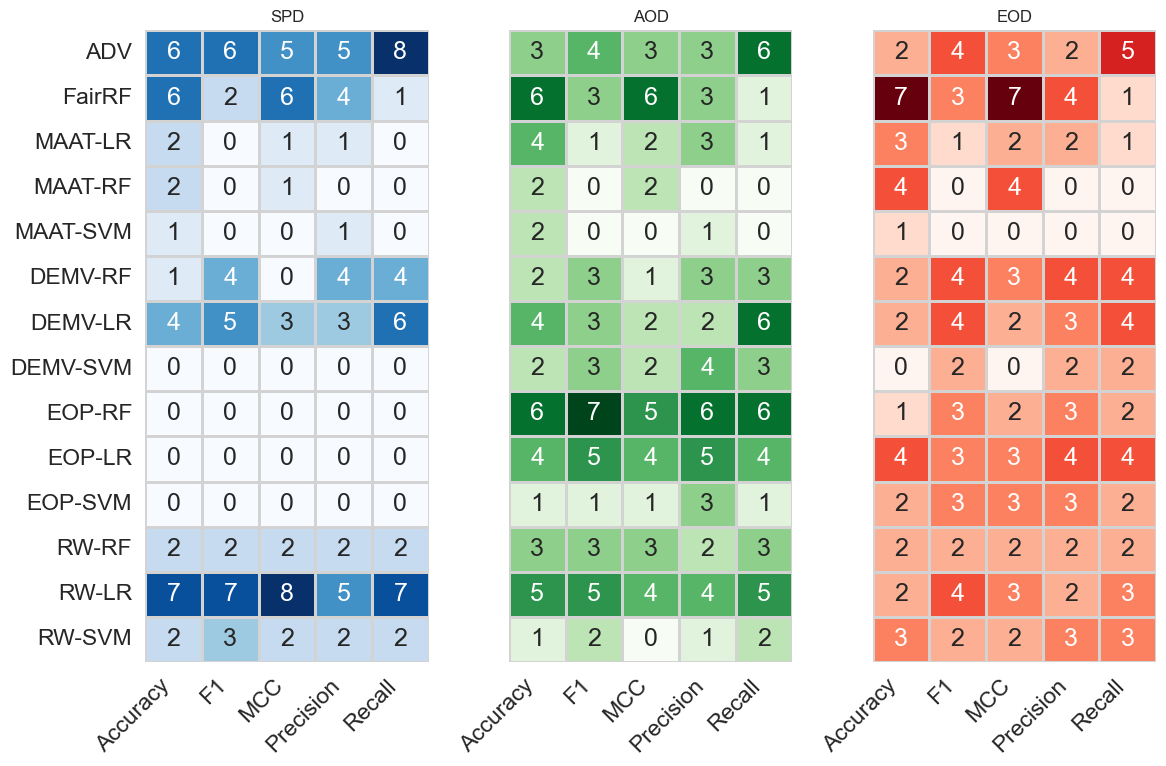

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True)

# Replace with your real keys
keys = ["SPD", "AOD", "EOD"]
cols = {"SPD":"Blues","AOD":"Greens","EOD":"Reds"}
for i, (ax, key) in enumerate(zip(axes, keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v1.pdf", bbox_inches="tight")
plt.show()